In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score, make_scorer

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


RANDOM_STATE = 280926

In [ ]:
train = pd.read_csv("QSAR_challenge_train_80pct.csv")
test = pd.read_csv("QSAR_challenge_test_20pct_NO_TARGETS.csv")

In [12]:
print(train.info())
print(test.info())

<class 'pandas.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sample_id              623 non-null    str    
 1   nHM                    612 non-null    float64
 2   piPC09                 610 non-null    float64
 3   PCD                    616 non-null    float64
 4   X2Av                   611 non-null    float64
 5   MLOGP                  610 non-null    float64
 6   ON1V                   609 non-null    float64
 7   N-072                  604 non-null    float64
 8   B02[C-N]               616 non-null    float64
 9   F04[C-O]               607 non-null    float64
 10  regression_target      623 non-null    float64
 11  classification_target  623 non-null    int64  
dtypes: float64(10), int64(1), str(1)
memory usage: 58.5 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 10 columns):
 #   Column     Non

In [14]:
feature_cols = [
    c for c in test.columns
    if c != "sample_id"]

reg_tafget = train["regression_target"]
cls_target = train["classification_target"]

In [15]:
feature_cols

['nHM',
 'piPC09',
 'PCD',
 'X2Av',
 'MLOGP',
 'ON1V',
 'N-072',
 'B02[C-N]',
 'F04[C-O]']

In [ ]:
# Imputation

from sklearn.experimental import enable_iterative_imputer  # Mandatory line
from sklearn.impute import IterativeImputer

X_train = train[feature_cols].copy()
X_test = test[feature_cols].copy()

im = IterativeImputer(random_state=RANDOM_STATE)
X_train_imputed = pd.DataFrame(im.fit_transform(X_train), columns=feature_cols)

X_test_imputed = pd.DataFrame(im.transform(X_test), columns=feature_cols)

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

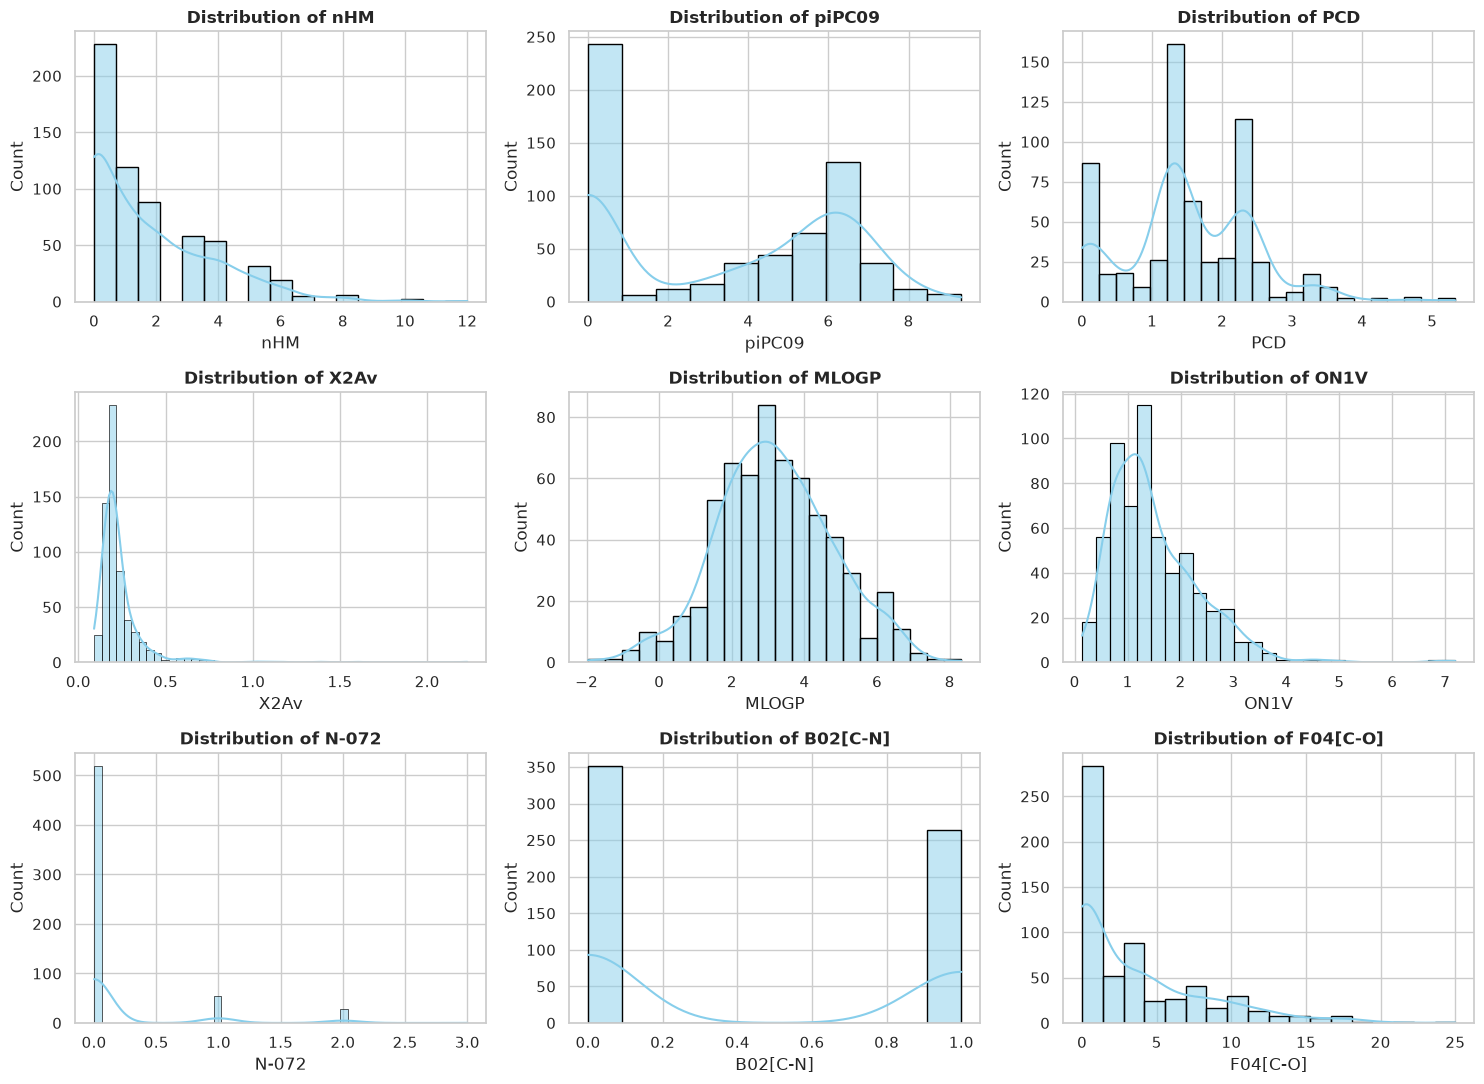

In [22]:
sns.set_theme(style="whitegrid")

# Select only the predictor features
feature_cols = [c for c in X_train_imputed.columns]

# Create a grid of subplots (3x3 grid for 9 features)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 11))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    sns.histplot(
        data=train,
        x=col,
        kde=True,
        ax=axes[idx],
        color="skyblue",
        edgecolor="black"
    )
    axes[idx].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Count")

plt.tight_layout()
plt.show()

- nHM and ON1V are right-skewed
- piPC09, N-072, F04[C-O] zero-inflated
- B02[C-O] is binary 
- features are scaled differently

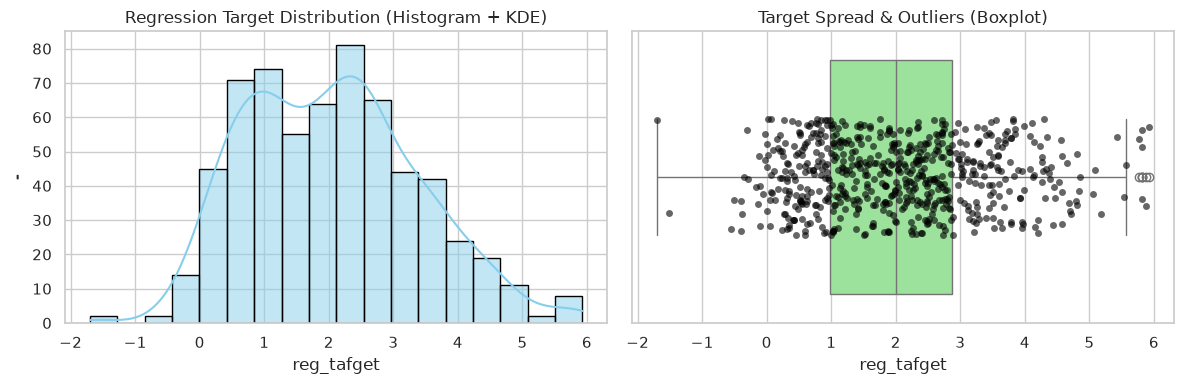

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Histogram + KDE
sns.histplot(reg_tafget, kde=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Regression Target Distribution (Histogram + KDE)')
axes[0].set_xlabel('reg_tafget')
axes[0].set_ylabel('-')

# 2. Boxplot
sns.boxplot(x=reg_tafget, ax=axes[1], color='lightgreen')

# 2. Overlay the individual points
sns.stripplot(
    x=reg_tafget, 
    ax=axes[1], 
    color='black',    # Color of the points
    alpha=0.6,        # Transparency so overlapping points are visible
    jitter=0.2        # Spreads points horizontally to avoid overlapping into a single line
)

axes[1].set_title('Target Spread & Outliers (Boxplot)')
axes[1].set_xlabel('reg_tafget')

plt.tight_layout()
plt.show()


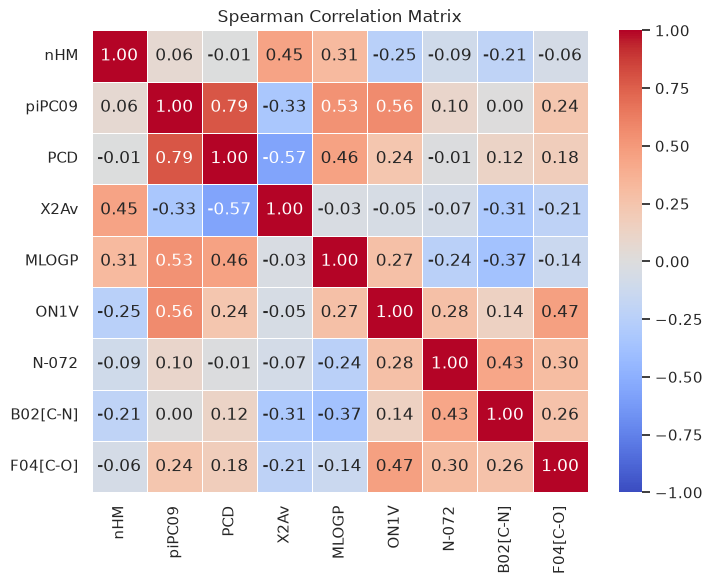

In [27]:
spearman_corr = X_train_imputed.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_corr,
    annot=True,  # Displays the correlation coefficient value inside each cell
    cmap='coolwarm',  # Color map (blue = negative, red = positive)
    fmt='.2f',  # Format numbers to 2 decimal places
    vmin=-1,
    vmax=1,  # Fixes the color scale from -1 to 1
    linewidths=0.5,  # Adds grid lines between cells
)

plt.title('Spearman Correlation Matrix')
plt.show()

In [28]:
spearman_corr

,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O]
nHM,1.000000,0.064784,-0.005095,0.451911,0.313920,-0.247832,-0.094992,-0.209551,-0.062880
piPC09,0.064784,1.000000,0.787201,-0.334986,0.531414,0.563837,0.099658,0.002996,0.236439
PCD,-0.005095,0.787201,1.000000,-0.567991,0.459568,0.238050,-0.009423,0.124413,0.179571
X2Av,0.451911,-0.334986,-0.567991,1.000000,-0.033767,-0.049843,-0.073499,-0.313347,-0.211921
MLOGP,0.313920,0.531414,0.459568,-0.033767,1.000000,0.273543,-0.240369,-0.367307,-0.139091
ON1V,-0.247832,0.563837,0.238050,-0.049843,0.273543,1.000000,0.277819,0.141897,0.466437
N-072,-0.094992,0.099658,-0.009423,-0.073499,-0.240369,0.277819,1.000000,0.430895,0.297237
B02[C-N],-0.209551,0.002996,0.124413,-0.313347,-0.367307,0.141897,0.430895,1.000000,0.262339
F04[C-O],-0.062880,0.236439,0.179571,-0.211921,-0.139091,0.466437,0.297237,0.262339,1.000000


In [31]:
cls_target.value_counts()

classification_target
1    368
3    204
2     51
Name: count, dtype: int64

## Data preparation

In [34]:
# define 5-fold split
from sklearn.model_selection import KFold

cv_reg = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

folds = list(cv_reg.split(X_train))

for fold, (train_idx, val_idx) in enumerate(folds, start=1):
    print(
        f"Fold {fold}: "
        f"train={len(train_idx)}, "
        f"validation={len(val_idx)}"
    )

Fold 1: train=498, validation=125
Fold 2: train=498, validation=125
Fold 3: train=498, validation=125
Fold 4: train=499, validation=124
Fold 5: train=499, validation=124


In [35]:
def prepare_fold(X_train, X_val, feature_cols, random_state):
    
    # ----- Imputation
    imputer = IterativeImputer(
        random_state=random_state
    )
    
    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=feature_cols,
        index=X_train.index
    )
    
    X_val_imp = pd.DataFrame(
        imputer.transform(X_val),
        columns=feature_cols,
        index=X_val.index
    )
    
    # ----- Scaling
    scaler = StandardScaler()
    
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_imp),
        columns=feature_cols,
        index=X_train.index
    )
    
    X_val_scaled = pd.DataFrame(
        scaler.transform(X_val_imp),
        columns=feature_cols,
        index=X_val.index
    )
    
    return (
        X_train_scaled,
        X_val_scaled,
        imputer,
        scaler
    )

In [39]:
## Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_reg = train["regression_target"]
y_cls = train["classification_target"]

fold_results = []

for fold, (train_idx, val_idx) in enumerate(folds, start=1):

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_reg.iloc[train_idx]
    y_fold_val = y_reg.iloc[val_idx]

    # preprocessing
    X_train_scaled, X_val_scaled, imputer, scaler = prepare_fold(
        X_fold_train,
        X_fold_val,
        feature_cols,
        RANDOM_STATE
    )

    # model
    model = LinearRegression()
    model.fit(X_train_scaled, y_fold_train)

    # prediction
    y_pred = model.predict(X_val_scaled)

    # metrics
    mae = mean_absolute_error(y_fold_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_fold_val, y_pred))
    r2 = r2_score(y_fold_val, y_pred)

    fold_results.append({
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_linear = pd.DataFrame(fold_results)

display(results_linear)
display(results_linear[["MAE", "RMSE", "R2"]].agg(["mean", "std"]))

,fold,MAE,RMSE,R2
0,1,0.606293,0.802150,0.627944
1,2,0.632080,0.826571,0.639514
2,3,0.597124,0.765670,0.606000
3,4,0.626244,0.790129,0.664654
4,5,0.654204,0.881238,0.572126


,MAE,RMSE,R2
mean,0.623189,0.813151,0.622048
std,0.022445,0.043936,0.035017
